In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#import csv file
df = pd.read_csv('/workspaces/Learning_Python/data/job_salary_prediction_dataset.csv')

In [4]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [5]:
#dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [6]:
#description of dataset
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [7]:
#find duplicates
df.duplicated().sum()  # No duplicates found

np.int64(0)

In [8]:
#find missing values
df.isnull().sum()  # No missing values found

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [9]:
#average salary by job title
job_salary = round(df.groupby('job_title')['salary'].mean().sort_values(ascending=False), 2)
print(job_salary)

job_title
AI Engineer                  173498.48
Machine Learning Engineer    163022.50
Product Manager              157594.93
Cloud Engineer               152102.54
DevOps Engineer              149959.27
Cybersecurity Analyst        148697.70
Data Scientist               147258.21
Software Engineer            141739.52
Backend Developer            139202.77
Frontend Developer           132653.84
Business Analyst             122551.23
Data Analyst                 119891.70
Name: salary, dtype: float64


In [11]:
#average salary by industry
industry_salary = round(df.groupby('industry')['salary'].mean().sort_values(ascending = False),2)
industry_salary

industry
Education        145993.56
Media            145891.27
Telecom          145876.51
Technology       145863.81
Finance          145801.64
Healthcare       145760.00
Government       145613.87
Manufacturing    145530.60
Consulting       145451.64
Retail           145399.70
Name: salary, dtype: float64

In [12]:
#average salary by location
location_salary = round(df.groupby('location')['salary'].mean().sort_values(ascending = False),2)
location_salary

location
USA            181716.30
Canada         167391.27
UK             160075.14
Germany        153376.21
Remote         139442.53
Sweden         139440.64
Australia      139362.15
Singapore      139340.70
Netherlands    139294.81
India           97690.40
Name: salary, dtype: float64

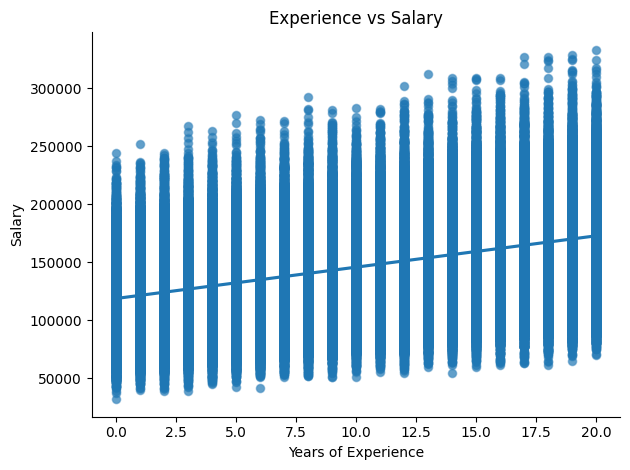

In [ ]:
#experience vs salary
sns.scatterplot(df, x='experience_years', y='salary',alpha=0.5)
sns.regplot(df, x='experience_years', y='salary', scatter_kws={'alpha':0.4})
plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

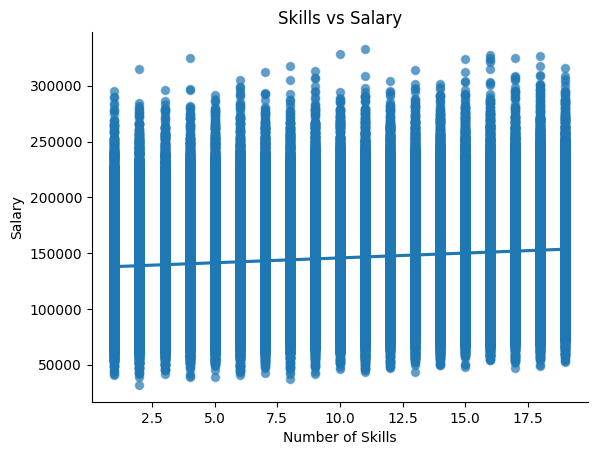

In [30]:
#skill vs salary
sns.scatterplot(df, x='skills_count', y='salary',alpha=0.5)
sns.regplot(df, x='skills_count', y='salary', scatter_kws={'alpha':0.4})
plt.title('Skills vs Salary')
plt.xlabel('Number of Skills')
plt.ylabel('Salary')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()


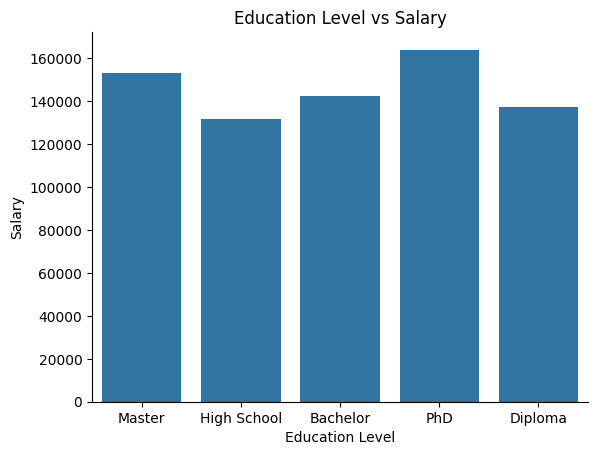

In [47]:
#education vs salary
sns.barplot(df, x='education_level', y='salary', errorbar = None, order = df['education_level'].value_counts().index)
plt.title('Education Level vs Salary')
plt.xlabel('Education Level')
plt.ylabel('Salary')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

In [49]:
#remote work analysis
remote_salary = round(df.groupby('remote_work')['salary'].mean(),2)
remote_salary

remote_work
Hybrid    143969.90
No        143932.30
Yes       149279.59
Name: salary, dtype: float64